In [18]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

In [2]:
from pathlib import Path

Path.cwd()

WindowsPath('c:/Users/Rudolf/Desktop/CreditCardFraud-MMBHJ/notebooks')

In [3]:
import sys
sys.path.append("..")

from src.io_utils import load_csv_to_dataframe

df = load_csv_to_dataframe("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.sum(), y_val.sum(), y_test.sum())

(199364, 30) (42721, 30) (42722, 30)
344 74 74


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(199364, 30)
(42721, 30)


In [11]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train);

In [12]:
y_val_pred = model.predict(X_val_scaled)
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

In [13]:
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
pr_auc = average_precision_score(y_val, y_val_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("PR-AUC:", pr_auc)

Precision: 0.7857142857142857
Recall: 0.5945945945945946
F1-score: 0.676923076923077
PR-AUC: 0.6703758418163931


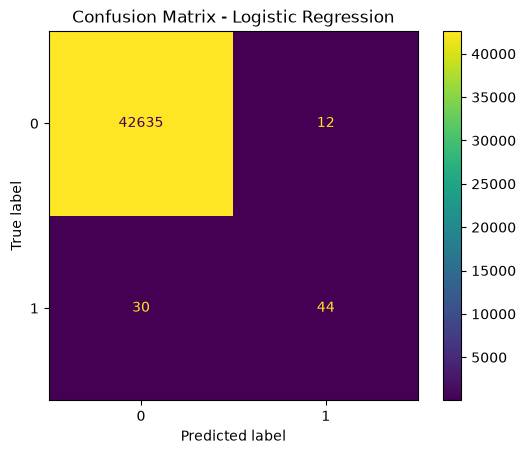

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

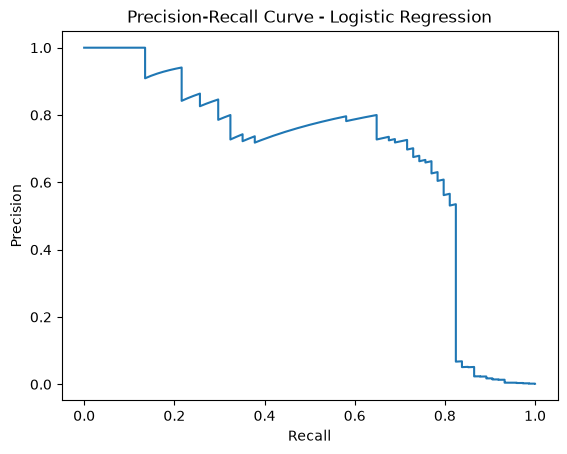

In [17]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

### Resultat för baseline

Modellen hittade 44 av 74 bedrägerier i validation-datan.

- Precision: 0.786
- Recall: 0.595
- F1-score: 0.677
- PR-AUC: 0.670

Modellen är ganska bra på att ha rätt när den säger att en transaktion är bedrägeri.

Men modellen missar fortfarande många bedrägerier.

Det här resultatet kan användas som jämförelse med andra modeller senare.

In [19]:
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

joblib.dump(model, model_dir / "baseline_model.joblib")
joblib.dump(scaler, model_dir / "baseline_scaler.joblib")

['..\\models\\baseline_scaler.joblib']

In [20]:
loaded_model = joblib.load("../models/baseline_model.joblib")
loaded_scaler = joblib.load("../models/baseline_scaler.joblib")

X_val_loaded = loaded_scaler.transform(X_val)
y_val_pred_loaded = loaded_model.predict(X_val_loaded)

print((y_val_pred_loaded == y_val_pred).all())

True


### Kontroll av sparad modell

Här kontrolleras att den sparade modellen och scalern går att läsa in och ger samma resultat.